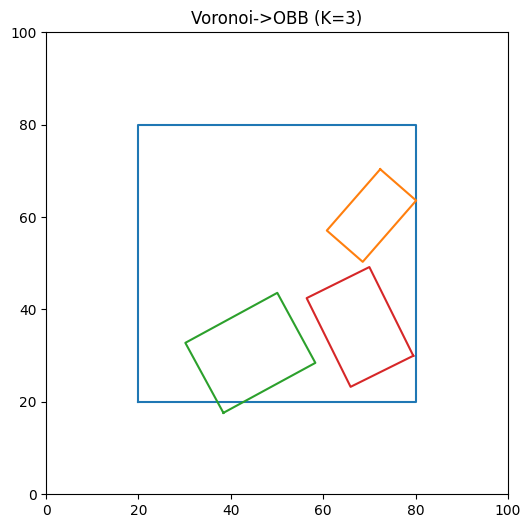

In [ ]:

# voronoi_obb_tiling.py
# - Rectangle exact tiling with min-only constraints
# - General polygon: grid-CVT Voronoi -> per-cell OBB fit (PCA)
import numpy as np
from matplotlib.path import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Optional

@dataclass
class Box:
    cx: float; cy: float; theta: float; w: float; h: float

@dataclass
class MinOnlyBounds:
    wmin: float = 10.0; hmin: float = 10.0

@dataclass
class Grid:
    W: int = 100; H: int = 100; dx: float = 1.0; dy: float = 1.0

def make_rectangle_polygon(x0,y0,x1,y1):
    return np.array([[x0,y0],[x1,y0],[x1,y1],[x0,y1]], dtype=float)

def is_rectangle(poly, atol=1e-6):
    if poly.shape[0] != 4: return False
    v0 = poly[1]-poly[0]; v1 = poly[2]-poly[1]; v2 = poly[3]-poly[2]; v3 = poly[0]-poly[3]
    if not (np.isclose(np.dot(v0,v1),0.0,atol=1e-5) and np.isclose(np.dot(v1,v2),0.0,atol=1e-5)):
        return False
    return (np.isclose(np.linalg.norm(v0), np.linalg.norm(v2), atol=atol) and
            np.isclose(np.linalg.norm(v1), np.linalg.norm(v3), atol=atol))

def rect_geom_from_poly(poly):
    p0,p1,p2,p3 = poly
    v_w = p1-p0; v_h = p2-p1
    W = float(np.linalg.norm(v_w)); H = float(np.linalg.norm(v_h))
    theta = float(np.arctan2(v_w[1], v_w[0]))
    c = (p0+p2)/2.0
    return c, W, H, theta

def corners_of_box(b: Box):
    hw, hh = b.w*0.5, b.h*0.5
    local = np.array([[-hw,-hh],[ hw,-hh],[ hw, hh],[-hw, hh]])
    ct, st = np.cos(b.theta), np.sin(b.theta)
    R = np.array([[ct,-st],[st,ct]])
    return local @ R.T + np.array([b.cx,b.cy])

def draw(poly, boxes, title=""):
    fig = plt.figure(figsize=(6,6)); ax = plt.gca()
    closed = np.vstack([poly, poly[0]]); ax.plot(closed[:,0], closed[:,1])
    for b in boxes:
        cs = np.vstack([corners_of_box(b), corners_of_box(b)[0]])
        ax.plot(cs[:,0], cs[:,1])
    ax.set_aspect("equal","box"); ax.set_xlim(0,100); ax.set_ylim(0,100); ax.set_title(title); plt.show()

def tile_rectangle_minOnly(poly, K, bounds: MinOnlyBounds):
    c, W, H, theta = rect_geom_from_poly(poly)
    feasible_vertical = (H >= bounds.hmin) and (W >= K*bounds.wmin)
    feasible_horizontal = (W >= bounds.wmin) and (H >= K*bounds.hmin)
    if not (feasible_vertical or feasible_horizontal):
        return [], dict(feasible=False)
    slack_vert = (H - bounds.hmin) + (W - K*bounds.wmin) if feasible_vertical else -1e9
    slack_horz = (W - bounds.wmin) + (H - K*bounds.hmin) if feasible_horizontal else -1e9
    orient = "vertical" if slack_vert >= slack_horz else "horizontal"
    boxes = []
    if orient == "vertical":
        widths = np.full(K, W / K)
        u = np.array([np.cos(theta), np.sin(theta)])
        left = c - 0.5*W*u
        for i in range(K):
            ctr = left + (i+0.5)*widths[i]*u
            boxes.append(Box(ctr[0], ctr[1], theta, widths[i], H))
    else:
        heights = np.full(K, H / K)
        v = np.array([-np.sin(theta), np.cos(theta)])
        bot = c - 0.5*H*v
        for i in range(K):
            ctr = bot + (i+0.5)*heights[i]*v
            boxes.append(Box(ctr[0], ctr[1], theta, W, heights[i]))
    return boxes, dict(feasible=True, orientation=orient)

def points_in_polygon(points, poly):
    return Path(poly, closed=True).contains_points(points)

def cvt_voronoi_seeds(poly, K, grid: Grid, iters=3, seed=0):
    xs = np.arange(grid.W)*grid.dx + 0.5*grid.dx
    ys = np.arange(grid.H)*grid.dy + 0.5*grid.dy
    X,Y = np.meshgrid(xs, ys, indexing="xy")
    pts = np.stack([X.reshape(-1), Y.reshape(-1)], axis=1)
    inside = points_in_polygon(pts, poly)
    P = pts[inside]
    rng = np.random.default_rng(seed)
    seeds = P[rng.choice(len(P), size=K, replace=False)]
    for _ in range(iters):
        d = np.sum((P[:,None,:]-seeds[None,:,:])**2, axis=2)
        idx = np.argmin(d, axis=1)
        for k in range(K):
            m = (idx==k)
            if np.any(m): seeds[k] = P[m].mean(axis=0)
            else: seeds[k] = P[rng.integers(0, len(P))]
    return P, inside, seeds

def voronoi_cells(P, seeds):
    d = np.sum((P[:,None,:]-seeds[None,:,:])**2, axis=2)
    idx = np.argmin(d, axis=1)
    return [P[idx==k] for k in range(len(seeds))]

def pca_axes(points):
    c = points.mean(axis=0)
    X = points - c
    if len(points) < 2:
        return c, np.array([1.0,0.0]), np.array([0.0,1.0])
    U,S,Vt = np.linalg.svd(X, full_matrices=False)
    u = Vt[0]; v = Vt[1] if Vt.shape[0]>1 else np.array([-u[1],u[0]])
    return c, u/np.linalg.norm(u), v/np.linalg.norm(v)

def obb_extents(points, c, u, v):
    pu = (points - c) @ u; pv = (points - c) @ v
    return pu.min(), pu.max(), pv.min(), pv.max()

def corners_in_cell(corners, seed, other_seeds):
    if other_seeds.size==0: return True
    own = np.sum((corners - seed[None,:])**2, axis=1)
    oth = np.min(np.sum((corners[:,None,:]-other_seeds[None,:,:])**2, axis=2), axis=1)
    return np.all(own <= oth + 1e-6)

def fit_box_in_cell(cell_pts, seed, other_seeds, bounds: MinOnlyBounds, shrink=0.9):
    c, u, v = pca_axes(cell_pts); u = u/(np.linalg.norm(u)+1e-12); v = np.array([-u[1],u[0]])
    umin, umax, vmin, vmax = obb_extents(cell_pts, c, u, v)
    w = max(bounds.wmin, (umax-umin)*shrink); h = max(bounds.hmin, (vmax-vmin)*shrink)
    theta = float(np.arctan2(u[1], u[0])); b = Box(c[0], c[1], theta, w, h)
    for _ in range(200):
        cs = corners_of_box(b)
        if corners_in_cell(cs, seed, other_seeds): return b
        b.w = max(bounds.wmin, b.w*0.95); b.h = max(bounds.hmin, b.h*0.95)
    return b

def voronoi_obb_tiling(poly, K, bounds: MinOnlyBounds, grid: Grid, cvt_iters=3, seed=0):
    P, _, seeds = cvt_voronoi_seeds(poly, K, grid, iters=cvt_iters, seed=seed)
    cells = voronoi_cells(P, seeds)
    boxes = []
    for k in range(K):
        pts = cells[k]
        if len(pts)==0:
            boxes.append(Box(seeds[k,0], seeds[k,1], 0.0, bounds.wmin, bounds.hmin))
        else:
            other = np.delete(seeds, k, axis=0)
            boxes.append(fit_box_in_cell(pts, seeds[k], other, bounds, shrink=0.9))
    return boxes

def demo():
    K=3
    bounds=MinOnlyBounds(10,10)
    grid=Grid(100,100,1.0,1.0)
    poly = make_rectangle_polygon(20,20,80,80)

    boxes = voronoi_obb_tiling(poly, K, bounds, grid, cvt_iters=3, seed=7)
    draw(poly, boxes, f"Voronoi->OBB (K={K})")

if __name__ == '__main__':
    demo()


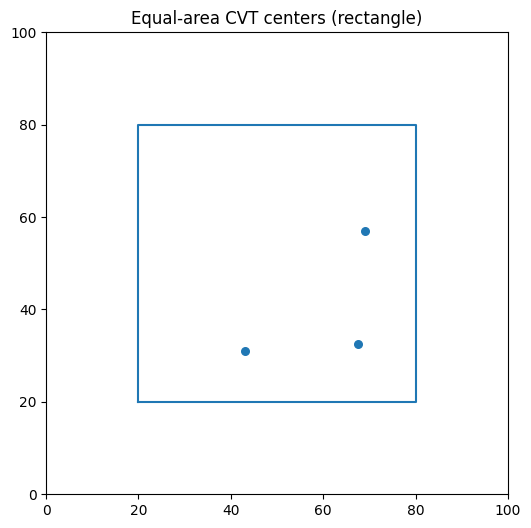

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from dataclasses import dataclass
from typing import Tuple, List

@dataclass
class Grid:
    W: int = 100
    H: int = 100
    dx: float = 1.0
    dy: float = 1.0

def points_in_polygon(points: np.ndarray, poly: np.ndarray) -> np.ndarray:
    return Path(poly, closed=True).contains_points(points)

def make_grid_points(grid: Grid) -> np.ndarray:
    xs = np.arange(grid.W) * grid.dx + 0.5 * grid.dx
    ys = np.arange(grid.H) * grid.dy + 0.5 * grid.dy
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    return np.stack([X.reshape(-1), Y.reshape(-1)], axis=1)

def uniform_points_in_polygon(poly: np.ndarray, grid: Grid) -> np.ndarray:
    pts = make_grid_points(grid)
    mask = points_in_polygon(pts, poly)
    return pts[mask]

def balanced_assignment(P: np.ndarray, centers: np.ndarray, quota: List[int]) -> np.ndarray:
    D = np.sum((P[:, None, :] - centers[None, :, :])**2, axis=2)  # (M,K)
    pref = np.argsort(D, axis=1)                                  # (M,K)
    order = np.argsort(D[np.arange(D.shape[0]), pref[:, 0]])      # process easy points first
    cap = np.array(quota, dtype=int).copy()
    idx = -np.ones(P.shape[0], dtype=int)
    for p in order:
        for c in pref[p]:
            if cap[c] > 0:
                idx[p] = c; cap[c] -= 1; break
    unassigned = np.where(idx < 0)[0]
    if len(unassigned) > 0:
        nn = np.argmin(D[unassigned], axis=1)
        idx[unassigned] = nn
    return idx

def project_to_polygon_if_needed(candidate: np.ndarray, poly: np.ndarray, pts_in_cell: np.ndarray) -> np.ndarray:
    inside = points_in_polygon(candidate[None, :], poly)[0]
    if inside: return candidate
    if len(pts_in_cell) == 0: return candidate
    d2 = np.sum((pts_in_cell - candidate[None, :])**2, axis=1)
    return pts_in_cell[np.argmin(d2)]

def equal_area_cvt_centers(poly: np.ndarray, K: int, grid: Grid, iters: int = 10, seed: int = 0) -> Tuple[np.ndarray, List[np.ndarray]]:
    rng = np.random.default_rng(seed)
    P = uniform_points_in_polygon(poly, grid)
    if len(P) < K:
        raise ValueError("Not enough inside-grid points. Increase grid or reduce K.")
    centers = P[rng.choice(len(P), size=K, replace=False)]
    base = len(P) // K
    quota = [base] * K
    for i in range(len(P) - base * K):
        quota[i % K] += 1
    for _ in range(iters):
        idx = balanced_assignment(P, centers, quota)
        new_centers = centers.copy()
        for k in range(K):
            pts_k = P[idx == k]
            if len(pts_k) > 0:
                candi = pts_k.mean(axis=0)
                new_centers[k] = project_to_polygon_if_needed(candi, poly, pts_k)
            else:
                new_centers[k] = P[rng.integers(0, len(P))]
        if np.allclose(new_centers, centers, atol=1e-6):
            centers = new_centers; break
        centers = new_centers
    idx = balanced_assignment(P, centers, quota)
    final_cells = [P[idx == k] for k in range(K)]
    return centers, final_cells

# --- tiny demo ---
def make_rectangle_polygon(x0,y0,x1,y1):
    return np.array([[x0,y0],[x1,y0],[x1,y1],[x0,y1]], float)

def sample_concave_polygon():
    return np.array([[20,70],[80,70],[80,85],[55,85],[55,30],[45,30],[45,85],[20,85]], float)

def plot_poly_and_centers(poly, centers, title=""):
    fig = plt.figure(figsize=(6,6))
    ax = plt.gca()
    closed = np.vstack([poly, poly[0]])
    ax.plot(closed[:,0], closed[:,1])
    ax.scatter(centers[:,0], centers[:,1], s=30)
    ax.set_aspect("equal","box")
    ax.set_xlim(0,100); ax.set_ylim(0,100)
    ax.set_title(title)
    plt.show()

if __name__ == "__main__":
    grid = Grid(100,100,1.0,1.0)
    rect = make_rectangle_polygon(20,20,80,80)
    centers_rect, _ = equal_area_cvt_centers(rect, K=3, grid=grid, iters=8, seed=2)
    plot_poly_and_centers(rect, centers_rect, "Equal-area CVT centers (rectangle)")
